Saving Housing.csv to Housing (2).csv

--- TRAIN PERFORMANCE ---
MAE: 719242.8936724712
MSE: 968358188440.7242
R2 Score: 0.6859438988560158

--- TEST PERFORMANCE ---
MAE: 970043.403920164
MSE: 1754318687330.6675
R2 Score: 0.6529242642153177


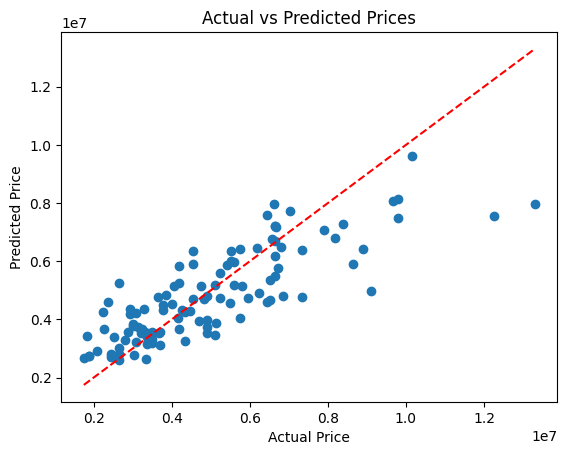

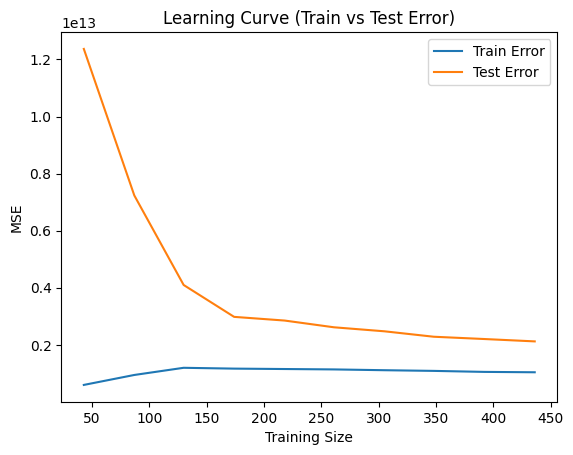


Feature Importance:
                             Feature    Coefficient
2                         bathrooms  549420.501241
0                              area  511615.563777
9               airconditioning_yes  367817.894916
3                           stories  353158.429856
10                     prefarea_yes  267018.660812
4                           parking  193542.781675
7                      basement_yes  186194.150506
8               hotwaterheating_yes  143233.206250
5                      mainroad_yes  128151.921295
6                     guestroom_yes   88590.213462
1                          bedrooms   56615.572458
11  furnishingstatus_semi-furnished  -62550.297211
12     furnishingstatus_unfurnished -193987.781088

Intercept: 4737518.175380117


In [3]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Upload data
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)


# 3. Preprocessing
# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop('price', axis=1)
y = df['price']

# Handle missing values
X = X.fillna(X.mean())


# 4. Feature Scaling (helps model stability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 6. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 7. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


# 8. Evaluation

print("\n--- TRAIN PERFORMANCE ---")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("R2 Score:", r2_score(y_train, y_train_pred))

print("\n--- TEST PERFORMANCE ---")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("R2 Score:", r2_score(y_test, y_test_pred))


# 9. Plot: Actual vs Predicted
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()


# 10. Learning Curve (Train vs Test Error)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_scaled, y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Convert negative MSE to positive
train_mse = -np.mean(train_scores, axis=1)
test_mse = -np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mse, label="Train Error")
plt.plot(train_sizes, test_mse, label="Test Error")

plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.title("Learning Curve (Train vs Test Error)")
plt.legend()
plt.show()


# 11. Feature Importance (Coefficients)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:\n", coeff_df.sort_values(by='Coefficient', ascending=False))


print("\nIntercept:", model.intercept_)